--- EJERCICIO 6.1: Benchmark de FFT y Agregado de Ceros ---
Tamaño Original: 247x372
Tamaño Óptimo (FFT): 250x375
Tamaño Subóptimo: 249x374

--- RESULTADOS DE TIEMPO ---
TDF Original: 5.39 ms
FFT Óptima:   3.23 ms (¡Más grande, pero más rápida!)
FFT Subóptima: 7.09 ms (El peor escenario)


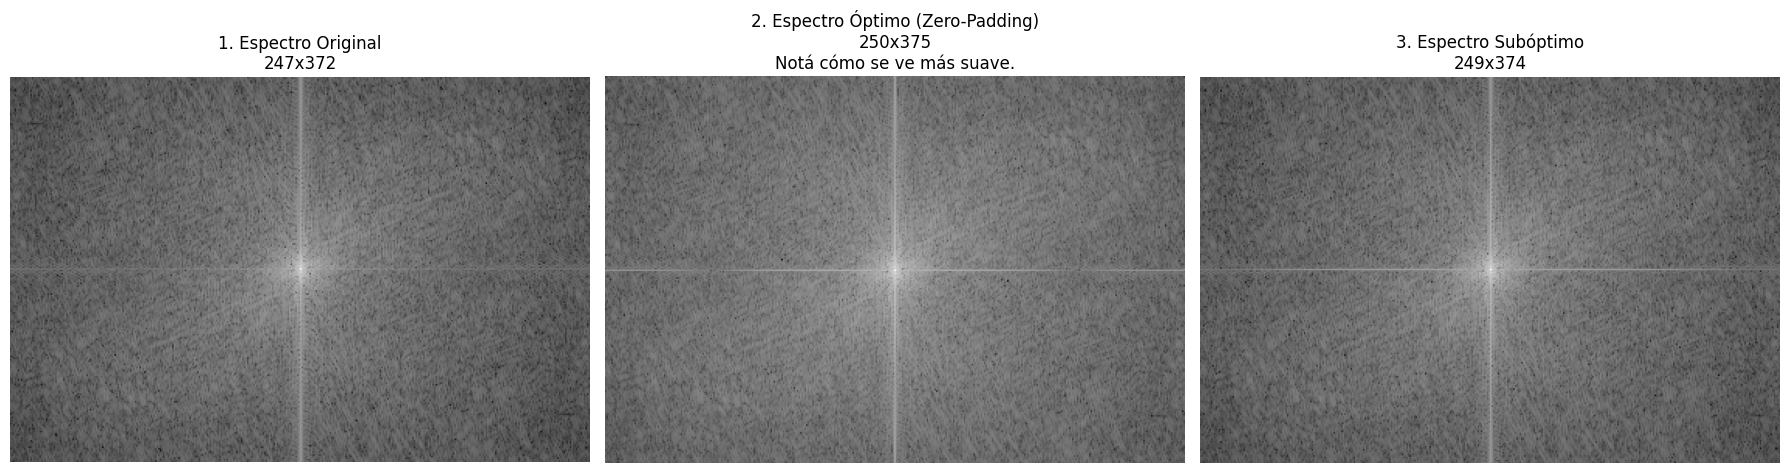

In [2]:
import cv2
import numpy as np
import timeit
import matplotlib.pyplot as plt

print("--- EJERCICIO 6.1: Benchmark de FFT y Agregado de Ceros ---")

# Cargamos una imagen grande para que el tiempo sea notorio
img = cv2.imread('camaleon.tif', cv2.IMREAD_GRAYSCALE)

if img is not None:
    filas, columnas = img.shape
    print(f"Tamaño Original: {filas}x{columnas}")
    
    # 1. Obtener tamaño óptimo
    filas_opt = cv2.getOptimalDFTSize(filas)
    col_opt = cv2.getOptimalDFTSize(columnas)
    print(f"Tamaño Óptimo (FFT): {filas_opt}x{col_opt}")
    
    # 2. Imagen Óptima (Agregando ceros a la derecha y abajo)
    img_opt = cv2.copyMakeBorder(img, 0, filas_opt - filas, 0, col_opt - columnas, 
                                 cv2.BORDER_CONSTANT, value=0)
    
    # 3. Imagen Subóptima (Óptimo - 1)
    filas_sub = filas_opt - 1
    col_sub = col_opt - 1
    print(f"Tamaño Subóptimo: {filas_sub}x{col_sub}")
    img_sub = cv2.copyMakeBorder(img, 0, filas_sub - filas, 0, col_sub - columnas, 
                                 cv2.BORDER_CONSTANT, value=0)
    
    # --- MEDICIÓN DE TIEMPOS ---
    def medir_tiempo_fft(imagen, iteraciones=50):
        # Medimos varias veces para tener un promedio real
        inicio = timeit.default_timer()
        for _ in range(iteraciones):
            _ = np.fft.fft2(imagen)
        fin = timeit.default_timer()
        return ((fin - inicio) / iteraciones) * 1000 # En milisegundos

    t_orig = medir_tiempo_fft(img)
    t_opt = medir_tiempo_fft(img_opt)
    t_sub = medir_tiempo_fft(img_sub)

    print("\n--- RESULTADOS DE TIEMPO ---")
    print(f"TDF Original: {t_orig:.2f} ms")
    print(f"FFT Óptima:   {t_opt:.2f} ms (¡Más grande, pero más rápida!)")
    print(f"FFT Subóptima: {t_sub:.2f} ms (El peor escenario)")

    # --- VISUALIZACIÓN ---
    def obtener_espectro(imagen):
        fshift = np.fft.fftshift(np.fft.fft2(imagen))
        return np.log(np.abs(fshift) + 1)

    fig, axs = plt.subplots(1, 3, figsize=(18, 6))
    
    axs[0].imshow(obtener_espectro(img), cmap='gray')
    axs[0].set_title(f"1. Espectro Original\n{filas}x{columnas}")
    axs[0].axis('off')
    
    axs[1].imshow(obtener_espectro(img_opt), cmap='gray')
    axs[1].set_title(f"2. Espectro Óptimo (Zero-Padding)\n{filas_opt}x{col_opt}\nNotá cómo se ve más suave.")
    axs[1].axis('off')
    
    axs[2].imshow(obtener_espectro(img_sub), cmap='gray')
    axs[2].set_title(f"3. Espectro Subóptimo\n{filas_sub}x{col_sub}")
    axs[2].axis('off')
    
    plt.tight_layout()
    plt.show()

else:
    print("⚠️ Error: No se encontró 'camaleon.tif'.")

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("--- EJERCICIO 6.2: Preprocesamiento OCR (Deskew / Alineación) ---")

def corregir_rotacion_texto(img_path):
    # 1. Cargar la imagen
    img = cv2.imread(img_path)
    if img is None:
        print(f"⚠️ Error: No se encontró '{img_path}'.")
        return
        
    img_gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # 2. Invertir la imagen (Texto blanco sobre fondo negro)
    # OpenCV necesita que los objetos de interés sean blancos (valor > 0)
    img_inv = cv2.bitwise_not(img_gris)
    
    # 3. Binarización (Separar bien el texto del fondo)
    _, thresh = cv2.threshold(img_inv, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
    
    # 4. Obtener las coordenadas de todos los píxeles blancos (el texto)
    coordenadas = np.column_stack(np.where(thresh > 0))
    
    # 5. Encontrar el rectángulo rotado que encierra todo el texto
    # minAreaRect devuelve: (centro(x, y), (ancho, alto), ángulo_de_rotación)
    rectangulo = cv2.minAreaRect(coordenadas)
    angulo = rectangulo[-1]
    
    # 6. Corrección geométrica del ángulo
    # En OpenCV, el ángulo del rect suele estar entre [0, 90).
    # Si el ancho es menor al alto, la caja está "parada", ajustamos el ángulo.
    (w, h) = rectangulo[1]
    if w < h:
        angulo = angulo - 90
        
    print(f"Ángulo detectado en '{img_path}': {angulo:.2f} grados")
    
    # 7. Si el ángulo es muy chiquito (ej. 0 o -90 limpios), no rotamos
    if abs(angulo) < 0.5 or abs(angulo - 90) < 0.5 or abs(angulo + 90) < 0.5:
        print("La imagen ya está derecha.")
        img_rotada = img.copy()
    else:
        # 8. Calcular la matriz de rotación y aplicar transformación afín
        (alto, ancho) = img.shape[:2]
        centro = (ancho // 2, alto // 2)
        
        M = cv2.getRotationMatrix2D(centro, angulo, 1.0)
        
        # BORDER_REPLICATE hace que el espacio vacío que queda al rotar se llene 
        # estirando el color del borde original (blanco), en vez de quedar negro.
        img_rotada = cv2.warpAffine(img, M, (ancho, alto), 
                                    flags=cv2.INTER_CUBIC, 
                                    borderMode=cv2.BORDER_REPLICATE)
        
    # --- VISUALIZACIÓN ---
    fig, axs = plt.subplots(1, 2, figsize=(15, 7))
    
    axs[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axs[0].set_title("1. Texto Escaneado Original")
    axs[0].axis('off')
    
    axs[1].imshow(cv2.cvtColor(img_rotada, cv2.COLOR_BGR2RGB))
    axs[1].set_title(f"2. Texto Alineado para OCR\n(Rotación corregida: {angulo:.2f}°)")
    axs[1].axis('off')
    
    plt.tight_layout()
    plt.show()

# Probalo con las imágenes que te dio el profe
# corregir_rotacion_texto('parrafo0.jpg')
corregir_rotacion_texto('parrafo1.jpg')

--- EJERCICIO 6.2: Preprocesamiento OCR (Deskew / Alineación) ---
⚠️ Error: No se encontró 'parrafo1.jpg'.
